# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abood-arc/Flyrank-ml-project/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

In [3]:
%pip -q install duckdb huggingface_hub

import os
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{os.environ['HF_TOKEN']}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
FACT_MAR    = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"


In [4]:
raw = con.sql(f"""
    SELECT
        f.content_hash_id,
        ANY_VALUE(f.client_hash_id)                                                       AS client_hash_id,
        MAX(f.gsc_data_available::INT)                                                     AS gsc_data_available,
        MAX(f.ga4_data_available::INT)                                                     AS ga4_data_available,
        SUM(CASE WHEN f.gsc_data_available IS TRUE THEN f.gsc_impressions ELSE 0 END)      AS gsc_impressions,
        SUM(CASE WHEN f.gsc_data_available IS TRUE THEN f.gsc_clicks ELSE 0 END)           AS gsc_clicks,
        AVG(CASE WHEN f.gsc_data_available IS TRUE THEN f.gsc_avg_position END)            AS gsc_avg_position,
        SUM(CASE WHEN f.ga4_data_available IS TRUE THEN f.ga4_sessions ELSE 0 END)         AS ga4_sessions,
        SUM(CASE WHEN f.ga4_data_available IS TRUE THEN f.ga4_engaged_sessions ELSE 0 END) AS ga4_engaged_sessions,
        SUM(CASE WHEN f.ga4_data_available IS TRUE THEN f.ga4_total_engagement_sec ELSE 0 END) AS ga4_total_engagement_sec,
        SUM(CASE WHEN f.ga4_data_available IS TRUE THEN f.scroll_events ELSE 0 END)        AS scroll_events,
        SUM(CASE WHEN f.ga4_data_available IS TRUE THEN f.sessions_ai ELSE 0 END)          AS sessions_ai,
        ANY_VALUE(c.word_count)     AS word_count,
        ANY_VALUE(c.search_volume)  AS search_volume,
        ANY_VALUE(c.competition)    AS competition,
        ANY_VALUE(c.content_type)   AS content_type,
        ANY_VALUE(c.main_intent)    AS main_intent
    FROM {FACT_MAR} f
    LEFT JOIN {DIM_CONTENT} c ON f.content_hash_id = c.content_hash_id
    GROUP BY f.content_hash_id
""").df()

print(f'{len(raw):,} content items pulled')
raw.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

331,437 content items pulled


,content_hash_id,client_hash_id,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,ga4_total_engagement_sec,scroll_events,sessions_ai,word_count,search_volume,competition,content_type,main_intent
0,content_39d7361b4945d504,client_62f4a7e64f5e0096,1,<NA>,77.0,0.0,4.074107,0.0,0.0,0.0,0.0,0.0,3579,10,0.0,keyword article,informational
1,content_cec711b02f3bbde6,client_62f4a7e64f5e0096,1,<NA>,602.0,4.0,4.428747,0.0,0.0,0.0,0.0,0.0,2455,10,0.0,keyword article,informational
2,content_275b6f7f733016d4,client_62f4a7e64f5e0096,1,<NA>,810.0,1.0,4.866123,0.0,0.0,0.0,0.0,0.0,3653,10,0.0,keyword article,informational
3,content_ceaec531566ffcfc,client_62f4a7e64f5e0096,1,<NA>,82.0,0.0,8.978086,0.0,0.0,0.0,0.0,0.0,3096,10,0.0,keyword article,informational
4,content_755d951187fcd70a,client_62f4a7e64f5e0096,1,<NA>,1858.0,6.0,1.854929,0.0,0.0,0.0,0.0,0.0,3305,10,0.0,keyword article,informational


In [6]:
import numpy as np
import pandas as pd

fv = raw.copy()

# DuckDB can hand back pandas' nullable dtype (pd.NA) instead of plain NaN --
# force these to numpy float64 so comparisons and np.where behave normally.
numeric_cols = ['gsc_impressions', 'gsc_clicks', 'gsc_avg_position',
                 'ga4_sessions', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
                 'scroll_events', 'sessions_ai', 'word_count', 'search_volume', 'competition']
fv[numeric_cols] = fv[numeric_cols].astype('float64')

# Finding D: gsc_avg_position = 0 while gsc_data_available = 1 happens for ~0.4% of
# rows -- the same "0 means no data, not rank zero" trap documented for the starter
# CSV. Treat those as missing, not as a literal top rank.
fv.loc[(fv['gsc_data_available'] == 1) & (fv['gsc_avg_position'] == 0), 'gsc_avg_position'] = np.nan

# Finding B: ga4_data_available itself is NULL (not False) for ~21% of content items --
# every March row for that item had the flag undefined. Treat "never confirmed
# available" the same as "not available" for an availability flag specifically.
fv['ga4_data_available'] = fv['ga4_data_available'].fillna(0).astype(int)
fv['gsc_data_available'] = fv['gsc_data_available'].fillna(0).astype(int)

# Finding A: word_count's missingness is NOT explained by content_type alone
# (37.7% missing even within "keyword article") -- so unlike search_volume/
# competition/main_intent, it needs its own flag before filling with 0.
fv['has_word_count'] = fv['word_count'].notna().astype(int)

# Engineered ratios -- guard divide-by-zero as NaN, not inf.
fv['ctr']             = np.where(fv['gsc_impressions'] > 0, fv['gsc_clicks'] / fv['gsc_impressions'], np.nan)
fv['engagement_rate'] = np.where(fv['ga4_sessions'] > 0, fv['ga4_engaged_sessions'] / fv['ga4_sessions'], np.nan)
fv['has_ai_referral']  = (fv['sessions_ai'].fillna(0) > 0).astype(int)

# search_volume/competition/main_intent's missingness IS fully explained by
# content_type (100% missing for feedly articles) -- since content_type is already
# a feature below, a plain fill is safe here; the model can learn the association itself.
fv = pd.get_dummies(fv, columns=['content_type', 'main_intent'], dummy_na=True)

metric_cols = ['gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ctr',
               'ga4_sessions', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
               'scroll_events', 'engagement_rate', 'word_count', 'search_volume', 'competition']
fv[metric_cols] = fv[metric_cols].fillna(0)

print(f'{fv.shape[1]} columns, {len(fv):,} rows in the final feature vector')
print(f'remaining missing values anywhere: {fv.isna().sum().sum()}')
fv.head()


28 columns, 331,437 rows in the final feature vector
remaining missing values anywhere: 0


,content_hash_id,client_hash_id,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,ga4_total_engagement_sec,...,has_ai_referral,content_type_comparison article,content_type_feedly article,content_type_keyword article,content_type_nan,main_intent_commercial,main_intent_informational,main_intent_navigational,main_intent_transactional,main_intent_nan
0,content_39d7361b4945d504,client_62f4a7e64f5e0096,1,0,77.0,0.0,4.074107,0.0,0.0,0.0,...,0,False,False,True,False,False,True,False,False,False
1,content_cec711b02f3bbde6,client_62f4a7e64f5e0096,1,0,602.0,4.0,4.428747,0.0,0.0,0.0,...,0,False,False,True,False,False,True,False,False,False
2,content_275b6f7f733016d4,client_62f4a7e64f5e0096,1,0,810.0,1.0,4.866123,0.0,0.0,0.0,...,0,False,False,True,False,False,True,False,False,False
3,content_ceaec531566ffcfc,client_62f4a7e64f5e0096,1,0,82.0,0.0,8.978086,0.0,0.0,0.0,...,0,False,False,True,False,False,True,False,False,False
4,content_755d951187fcd70a,client_62f4a7e64f5e0096,1,0,1858.0,6.0,1.854929,0.0,0.0,0.0,...,0,False,False,True,False,False,True,False,False,False


## 2. Feature notes (meaning, missing, categorical, available-when?)

*For each feature: what it means, how missing values are handled, and whether it exists BEFORE the moment you predict.*

In [7]:
import pandas as pd

notes = pd.DataFrame([
    ("gsc_data_available",  "GSC tracked at least one day this March",         "NULL -> 0 (finding B: flag itself was undefined for ~21% of items)", "yes -- this IS the decision-time knowledge"),
    ("ga4_data_available",  "GA4 tracked at least one day this March",         "NULL -> 0 (same as above)",                                           "yes -- same"),
    ("gsc_impressions",     "total GSC impressions, March, GSC-tracked days only", "0 fill (real zero -- summed only over tracked days)",             "yes -- closed-day GSC aggregate"),
    ("gsc_clicks",          "total GSC clicks, same window",                   "0 fill",                                                              "yes -- same"),
    ("gsc_avg_position",    "avg GSC position across tracked days",            "0 fill, AFTER correcting literal 0 -> missing (finding D, ~0.4% of rows)", "yes -- same"),
    ("ga4_sessions",        "total GA4 sessions, GA4-tracked days only",       "0 fill",                                                              "yes -- gated by ga4_data_available"),
    ("ga4_engaged_sessions","total engaged sessions, same window",             "0 fill",                                                              "yes -- same"),
    ("ga4_total_engagement_sec", "total engagement seconds, same window",      "0 fill",                                                              "yes -- same"),
    ("scroll_events",       "total scroll events, same window",                "0 fill",                                                              "yes -- same"),
    ("sessions_ai",         "total AI-referral sessions, same window",         "0 fill (via has_ai_referral)",                                        "yes -- same"),
    ("word_count",          "article length, from dim_content",                "has_word_count flag added FIRST, then 0 fill (finding A: not fully explained by content_type)", "yes -- known at publish time, before any report_date"),
    ("has_word_count",      "1 if word_count was present, 0 if missing",       "n/a -- this IS the missingness indicator",                            "yes -- same"),
    ("search_volume",       "keyword search volume, from dim_content",         "0 fill (finding A: missingness fully explained by content_type, already a feature)", "yes -- known once keyword research was done"),
    ("competition",         "keyword competition score, from dim_content",     "0 fill (same reasoning as search_volume)",                            "yes -- same"),
    ("ctr",                 "gsc_clicks / gsc_impressions",                    "NaN when 0 impressions, then 0 fill",                                 "yes -- derived from already-safe features"),
    ("engagement_rate",     "ga4_engaged_sessions / ga4_sessions",             "NaN when 0 sessions, then 0 fill",                                    "yes -- same"),
    ("has_ai_referral",     "1 if sessions_ai > 0",                            "n/a -- binary derived, no missing",                                    "yes -- same"),
    ("content_type_* (4 dummies)", "one-hot of content_type (comparison/feedly/keyword article + a NaN indicator)", "dummy_na=True -- missing gets its own column, not erased", "yes -- known at publish time"),
    ("main_intent_* (5 dummies)",  "one-hot of main_intent (commercial/informational/navigational/transactional + NaN)", "dummy_na=True -- same",       "yes -- known at publish time"),
], columns=["feature", "meaning", "missing_handling", "available_before_decision_moment"])

pd.set_option('display.max_colwidth', None)
notes


,feature,meaning,missing_handling,available_before_decision_moment
0,gsc_data_available,GSC tracked at least one day this March,NULL -> 0 (finding B: flag itself was undefined for ~21% of items),yes -- this IS the decision-time knowledge
1,ga4_data_available,GA4 tracked at least one day this March,NULL -> 0 (same as above),yes -- same
2,gsc_impressions,"total GSC impressions, March, GSC-tracked days only",0 fill (real zero -- summed only over tracked days),yes -- closed-day GSC aggregate
3,gsc_clicks,"total GSC clicks, same window",0 fill,yes -- same
4,gsc_avg_position,avg GSC position across tracked days,"0 fill, AFTER correcting literal 0 -> missing (finding D, ~0.4% of rows)",yes -- same
5,ga4_sessions,"total GA4 sessions, GA4-tracked days only",0 fill,yes -- gated by ga4_data_available
6,ga4_engaged_sessions,"total engaged sessions, same window",0 fill,yes -- same
7,ga4_total_engagement_sec,"total engagement seconds, same window",0 fill,yes -- same
8,scroll_events,"total scroll events, same window",0 fill,yes -- same
9,sessions_ai,"total AI-referral sessions, same window",0 fill (via has_ai_referral),yes -- same


## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

In [9]:
raw = con.sql(f"""
    SELECT
        f.content_hash_id,
        ANY_VALUE(f.client_hash_id) AS client_hash_id,
        MAX(CASE WHEN f.report_date < DATE '2026-03-16' THEN f.gsc_data_available::INT END) AS gsc_available_feat,
        MAX(CASE WHEN f.report_date < DATE '2026-03-16' THEN f.ga4_data_available::INT END) AS ga4_available_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.gsc_data_available IS TRUE THEN f.gsc_impressions ELSE 0 END) AS gsc_impressions_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.gsc_data_available IS TRUE THEN f.gsc_clicks ELSE 0 END) AS gsc_clicks_feat,
        AVG(CASE WHEN f.report_date < DATE '2026-03-16' AND f.gsc_data_available IS TRUE THEN f.gsc_avg_position END) AS gsc_avg_position_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.ga4_data_available IS TRUE THEN f.ga4_sessions ELSE 0 END) AS ga4_sessions_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.ga4_data_available IS TRUE THEN f.ga4_engaged_sessions ELSE 0 END) AS ga4_engaged_sessions_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.ga4_data_available IS TRUE THEN f.ga4_total_engagement_sec ELSE 0 END) AS ga4_total_engagement_sec_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.ga4_data_available IS TRUE THEN f.scroll_events ELSE 0 END) AS scroll_events_feat,
        SUM(CASE WHEN f.report_date < DATE '2026-03-16' AND f.ga4_data_available IS TRUE THEN f.sessions_ai ELSE 0 END) AS sessions_ai_feat,
        -- label window: strictly AFTER every feature above, used only to build the label
        SUM(CASE WHEN f.report_date >= DATE '2026-03-16' AND f.gsc_data_available IS TRUE THEN f.gsc_impressions ELSE 0 END) AS gsc_impressions_label,
        ANY_VALUE(c.word_count)    AS word_count,
        ANY_VALUE(c.search_volume) AS search_volume,
        ANY_VALUE(c.competition)   AS competition,
        ANY_VALUE(c.content_type)  AS content_type,
        ANY_VALUE(c.main_intent)   AS main_intent
    FROM {FACT_MAR} f
    LEFT JOIN {DIM_CONTENT} c ON f.content_hash_id = c.content_hash_id
    GROUP BY f.content_hash_id
    HAVING gsc_impressions_feat >= 20
""").df()

fv = raw.copy()
numeric_cols = ['gsc_impressions_feat', 'gsc_clicks_feat', 'gsc_avg_position_feat',
                 'ga4_sessions_feat', 'ga4_engaged_sessions_feat', 'ga4_total_engagement_sec_feat',
                 'scroll_events_feat', 'sessions_ai_feat', 'gsc_impressions_label',
                 'word_count', 'search_volume', 'competition']
fv[numeric_cols] = fv[numeric_cols].astype('float64')
fv.loc[(fv['gsc_available_feat'] == 1) & (fv['gsc_avg_position_feat'] == 0), 'gsc_avg_position_feat'] = np.nan
fv['ga4_available_feat'] = fv['ga4_available_feat'].fillna(0).astype(int)
fv['gsc_available_feat'] = fv['gsc_available_feat'].fillna(0).astype(int)
fv['has_word_count'] = fv['word_count'].notna().astype(int)
fv['ctr']             = np.where(fv['gsc_impressions_feat'] > 0, fv['gsc_clicks_feat'] / fv['gsc_impressions_feat'], np.nan)
fv['engagement_rate'] = np.where(fv['ga4_sessions_feat'] > 0, fv['ga4_engaged_sessions_feat'] / fv['ga4_sessions_feat'], np.nan)
fv['has_ai_referral']  = (fv['sessions_ai_feat'].fillna(0) > 0).astype(int)
fv = pd.get_dummies(fv, columns=['content_type', 'main_intent'], dummy_na=True)

# Label -- built ONLY from the label window, never overlapping the features above
fv['pct_change']   = (fv['gsc_impressions_label'] - fv['gsc_impressions_feat']) / fv['gsc_impressions_feat']
fv['is_declining']  = (fv['pct_change'] < -0.2).astype(int)

metric_cols = ['gsc_impressions_feat', 'gsc_clicks_feat', 'gsc_avg_position_feat', 'ctr',
               'ga4_sessions_feat', 'ga4_engaged_sessions_feat', 'ga4_total_engagement_sec_feat',
               'scroll_events_feat', 'engagement_rate', 'word_count', 'search_volume', 'competition']
fv[metric_cols] = fv[metric_cols].fillna(0)

print(f'{len(fv):,} content items, {fv["client_hash_id"].nunique()} distinct clients')
print(f'base rate (declining): {fv["is_declining"].mean():.3f}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

109,592 content items, 41 distinct clients
base rate (declining): 0.291


In [10]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier

honest_features = [c for c in fv.columns if c not in
    ('content_hash_id', 'client_hash_id', 'gsc_impressions_label', 'pct_change', 'is_declining')]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

X, y, groups = fv[honest_features], fv['is_declining'], fv['client_hash_id']

# Grouped split -- no client's pages appear in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))
X_tr, X_te, y_tr, y_te = X.iloc[tr_idx], X.iloc[te_idx], y.iloc[tr_idx], y.iloc[te_idx]

model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1).fit(X_tr, y_tr)
p50_grouped = precision_at_k(model.predict_proba(X_te)[:, 1], y_te, 50)

# Random split, for comparison -- same rows, no client protection
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model_r = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1).fit(X_tr_r, y_tr_r)
p50_random = precision_at_k(model_r.predict_proba(X_te_r)[:, 1], y_te_r, 50)

print(f'base rate: {y.mean():.3f}')
print(f'Honest Precision@50 -- random split:  {p50_random:.3f}')
print(f'Honest Precision@50 -- grouped split: {p50_grouped:.3f}')


base rate: 0.291
Honest Precision@50 -- random split:  0.860
Honest Precision@50 -- grouped split: 0.580


In [11]:
leak1_features = honest_features + ['pct_change']
model_leak1 = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1).fit(fv.loc[tr_idx, leak1_features], y_tr)
leak1_p50 = precision_at_k(model_leak1.predict_proba(fv.loc[te_idx, leak1_features])[:, 1], y_te, 50)
print(f"LEAK 1 (pct_change, label-derived) Precision@50: {leak1_p50:.3f}")

leak2_features = honest_features + ['gsc_impressions_label']
model_leak2 = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1).fit(fv.loc[tr_idx, leak2_features], y_tr)
leak2_p50 = precision_at_k(model_leak2.predict_proba(fv.loc[te_idx, leak2_features])[:, 1], y_te, 50)
print(f"LEAK 2 (gsc_impressions_label, future window) Precision@50: {leak2_p50:.3f}")


LEAK 1 (pct_change, label-derived) Precision@50: 1.000
LEAK 2 (gsc_impressions_label, future window) Precision@50: 1.000


Text(0.5, 1.0, 'Honest model -- top 8 feature importances (grouped split)')

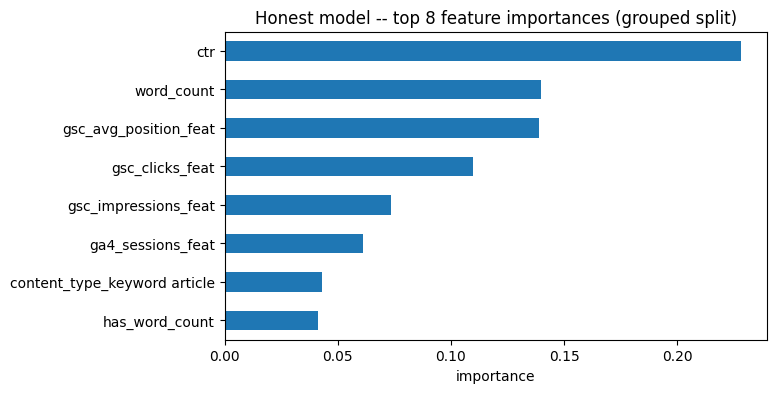

In [12]:
importances = pd.Series(model.feature_importances_, index=honest_features).sort_values()
ax = importances.tail(8).plot(kind='barh', figsize=(7,4))
ax.set_xlabel('importance')
ax.set_title('Honest model -- top 8 feature importances (grouped split)')


## 4. What I excluded and why

*The list of fields you refused to use — with one line of why each.*

In [13]:
print("""
last_optimized_date, optimization_eligible_date, is_deleted, is_published --
    dim_content is a single export-time snapshot, not per-report_date history;
    these can describe a state that didn't exist yet as of an earlier report_date.
    last_optimized_date has a second reason: it's downstream of a product decision.

provider_used, model_used, backlinks, category_count --
    undocumented anywhere I've read. Not featured on a guess.

pct_change, gsc_impressions_label --
    refused as features, not just in theory: section 3 proved both push Precision@50
    to a perfect 1.000 the moment they're added. pct_change is label-derived (the exact
    value is_declining is thresholded from); gsc_impressions_label is raw data from
    AFTER the feature window closes -- two different leakage mechanisms, same verdict.

client_hash_id --
    used only to build the grouped train/test split. Never fed to the model as a
    feature -- a client ID carries no real-world signal about content performance,
    it's a join/grouping key by construction.

ai_chatgpt/perplexity/gemini/copilot/claude/meta/other (7 individual columns) --
    not excluded, but deliberately collapsed into one has_ai_referral flag instead of
    used individually -- each is almost entirely zero on its own (AI referrals are
    thin overall), so seven near-empty dummy columns would be noise, not seven signals.
""")



last_optimized_date, optimization_eligible_date, is_deleted, is_published --
    dim_content is a single export-time snapshot, not per-report_date history;
    these can describe a state that didn't exist yet as of an earlier report_date.
    last_optimized_date has a second reason: it's downstream of a product decision.

provider_used, model_used, backlinks, category_count --
    undocumented anywhere I've read. Not featured on a guess.

pct_change, gsc_impressions_label --
    refused as features, not just in theory: section 3 proved both push Precision@50
    to a perfect 1.000 the moment they're added. pct_change is label-derived (the exact
    value is_declining is thresholded from); gsc_impressions_label is raw data from
    AFTER the feature window closes -- two different leakage mechanisms, same verdict.

client_hash_id --
    used only to build the grouped train/test split. Never fed to the model as a
    feature -- a client ID carries no real-world signal about content perfo

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.